# Part 3: Compression

In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

2026-03-16 17:58:39.065655: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Fetch the jet tagging dataset from Open ML

In [2]:
X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)

## Now construct a model
We'll use the same architecture as in part 1: 3 hidden layers with 64, then 32, then 32 neurons. Each layer will use `relu` activation.
Add an output layer with 5 neurons (one for each class), then finish with Softmax activation.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from callbacks import all_callbacks

In [4]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

## Train sparse
This time we'll use the Tensorflow model optimization sparsity to train a sparse model (forcing many weights to '0'). In this instance, the target sparsity is 75%

In [5]:
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

pruning_params = {"pruning_schedule": pruning_schedule.ConstantSparsity(0.75, begin_step=2000, frequency=100)}
model = prune.prune_low_magnitude(model, **pruning_params)

## Train the model
We'll use the same settings as the model for part 1: Adam optimizer with categorical crossentropy loss.
The callbacks will decay the learning rate and save the model into a directory 'model_2'
The model isn't very complex, so this should just take a few minutes even on the CPU.
If you've restarted the notebook kernel after training once, set `train = False` to load the trained model rather than training again.

In [6]:
train = True
if train:
    adam = Adam(lr=0.0001)
    model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='model_2',
    )
    callbacks.callbacks.append(pruning_callbacks.UpdatePruningStep())
    model.fit(
        X_train_val,
        y_train_val,
        batch_size=1024,
        epochs=10,
        validation_split=0.25,
        shuffle=True,
        callbacks=callbacks.callbacks,
    )
    # Save the model again but with the pruning 'stripped' to use the regular layer types
    model = strip_pruning(model)
    model.save('model_2/KERAS_check_best_model.h5')
else:
    from tensorflow.keras.models import load_model

    model = load_model('model_2/KERAS_check_best_model.h5')

Epoch 1/10
  1/487 [..............................] - ETA: 14:44 - loss: 1.6633 - accuracy: 0.2529WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0026s vs `on_train_batch_end` time: 0.0040s). Check your callbacks.


482/487 [============================>.] - ETA: 0s - loss: 0.9421 - accuracy: 0.6923
***callbacks***
saving losses to model_2/losses.log

Epoch 1: val_loss improved from inf to 0.81468, saving model to model_2/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 0.81468, saving model to model_2/KERAS_check_best_model_weights.h5

Epoch 1: saving model to model_2/KERAS_check_model_last.h5

Epoch 1: saving model to model_2/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 4s 4ms/step - loss: 0.9407 - accuracy: 0.6927 - val_loss: 0.8147 - val_accuracy: 0.7361 - lr: 0.0010
Epoch 2/10
 38/487 [=>............................] - ETA: 1s - loss: 0.8018 - accuracy: 0.7398

/home/ubuntu/anaconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


472/487 [============================>.] - ETA: 0s - loss: 0.7909 - accuracy: 0.7434
***callbacks***
saving losses to model_2/losses.log

Epoch 2: val_loss improved from 0.81468 to 0.78116, saving model to model_2/KERAS_check_best_model.h5

Epoch 2: val_loss improved from 0.81468 to 0.78116, saving model to model_2/KERAS_check_best_model_weights.h5

Epoch 2: saving model to model_2/KERAS_check_model_last.h5

Epoch 2: saving model to model_2/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 2s 3ms/step - loss: 0.7906 - accuracy: 0.7435 - val_loss: 0.7812 - val_accuracy: 0.7463 - lr: 0.0010
Epoch 3/10
472/487 [============================>.] - ETA: 0s - loss: 0.7679 - accuracy: 0.7493
***callbacks***
saving losses to model_2/losses.log

Epoch 3: val_loss improved from 0.78116 to 0.76587, saving model to model_2/KERAS_check_best_model.h5

Epoch 3: val_loss improved from 0.78116 to 0.76587, saving model to model_2/KERAS_check_best_model_weig

## Check sparsity
Make a quick check that the model was indeed trained sparse. We'll just make a histogram of the weights of the 1st layer, and hopefully observe a large peak in the bin containing '0'. Note logarithmic y axis.

% of zeros = 0.75


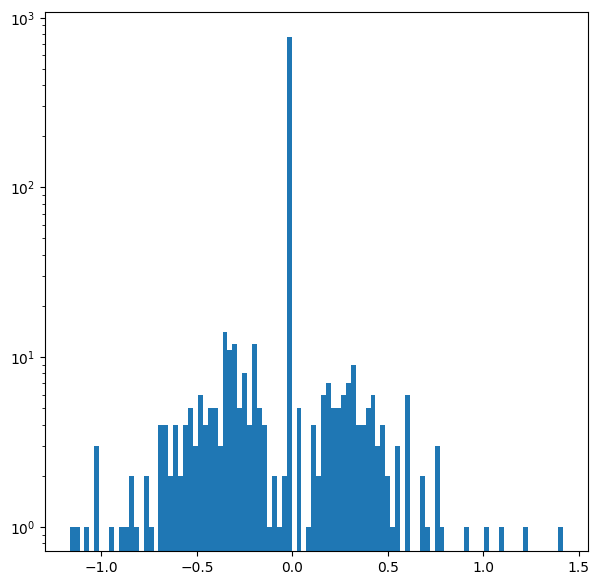

In [7]:
w = model.layers[0].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

## Check performance
How does this 75% sparse model compare against the unpruned model? Let's report the accuracy and make a ROC curve. The pruned model is shown with solid lines, the unpruned model from part 1 is shown with dashed lines.
**Make sure you've trained the model from part 1**

5188/5188 [==============================] - 5s 870us/step
Accuracy unpruned: 0.7579518072289156
Accuracy pruned:   0.7548192771084338


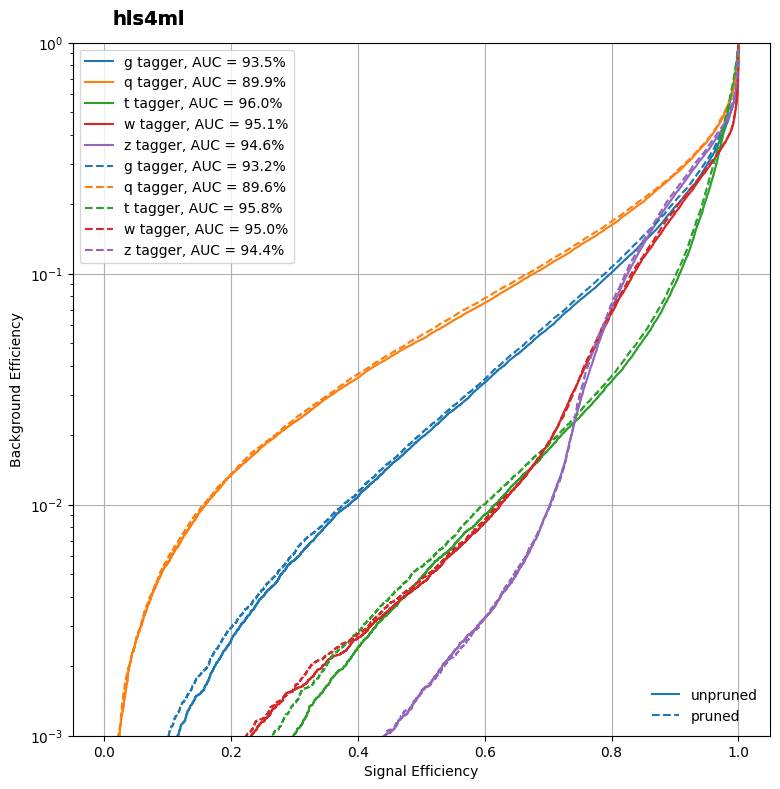

In [8]:
import plotting
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model

model_ref = load_model('model_1/KERAS_check_best_model.h5')

y_ref = model_ref.predict(X_test)
y_prune = model.predict(X_test)

print("Accuracy unpruned: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))
print("Accuracy pruned:   {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_prune, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_ref, classes)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_prune, classes, linestyle='--')

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
from matplotlib.legend import Legend

leg = Legend(ax, lines, labels=['unpruned', 'pruned'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Convert the model to FPGA firmware with hls4ml
Let's use the default configuration: `ap_fixed<16,6>` precision everywhere and `ReuseFactor=1`, so we can compare with the part 1 model. We need to use `strip_pruning` to change the layer types back to their originals.

**The synthesis will take a while**

While the C-Synthesis is running, we can monitor the progress looking at the log file by opening a terminal from the notebook home, and executing:

`tail -f model_2/hls4ml_prj/vitis_hls.log`

In [9]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='Vitis')
print(config)
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_2/hls4ml_prj', part='xck26-sfvc784-2LV-c'
)
hls_model.compile()
hls_model.build(csim=False)

{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}}

****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Mon Mar 16 18:03:40 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/ubuntu/work/hls4ml-tutorial/model_2/hls4ml_prj/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Creating and opening solution '/home/ubuntu/work/hls4ml-tutorial/model_2/hls4ml_prj/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c+

INFO: [HLS 200-1995] There were 5,913 instructions in the design after the 'Array/Struct (step 5)' phase of compilation. See the Design Size Report for more details (/home/ubuntu/work/hls4ml-tutorial/model_2/hls4ml_prj/myproject_prj/solution1/syn/report/csynth_design_size.rpt:2)
INFO: [HLS 200-1995] There were 5,913 instructions in the design after the 'Performance (step 1)' phase of compilation. See the Design Size Report for more details (/home/ubuntu/work/hls4ml-tutorial/model_2/hls4ml_prj/myproject_prj/solution1/syn/report/csynth_design_size.rpt:2)
INFO: [HLS 200-1995] There were 5,721 instructions in the design after the 'Performance (step 2)' phase of compilation. See the Design Size Report for more details (/home/ubuntu/work/hls4ml-tutorial/model_2/hls4ml_prj/myproject_prj/solution1/syn/report/csynth_design_size.rpt:2)
INFO: [HLS 200-1995] There were 5,527 instructions in the design after the 'Performance (step 3)' phase of compilation. See the Design Size Report for more detail

INFO: [HLS 200-111] Finished Standard Transforms: CPU user time: 0.21 seconds. CPU system time: 0.02 seconds. Elapsed time: 0.24 seconds; current allocated memory: 282.609 MB.
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [HLS 200-111] Finished Checking Synthesizability: CPU user time: 0.26 seconds. CPU system time: 0.01 seconds. Elapsed time: 0.27 seconds; current allocated memory: 286.074 MB.
INFO: [XFORM 203-11] Balancing expressions in function 'nnet::softmax_stable<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, softmax_config13>' (firmware/nnet_utils/nnet_activation.h:51:1)...4 expression(s) balanced.
INFO: [XFORM 203-11] Balancing expressions in function 'nnet::dense_latency<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config8>' (firmware/nnet_utils/nnet_dense_latency.h:33:27)...213 expression(s) balanced.
INFO: [XFORM 203-11] Balancing expressions in function 'nnet::dense

INFO: [SCHED 204-61] Pipelining function 'dense_latency<ap_fixed<16, 6, 5, 3, 0>, ap_fixed<16, 6, 5, 3, 0>, config8>'.
INFO: [HLS 200-1470] Pipelining result : Target II = NA, Final II = 1, Depth = 2, function 'dense_latency<ap_fixed<16, 6, 5, 3, 0>, ap_fixed<16, 6, 5, 3, 0>, config8>'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 0.68 seconds. CPU system time: 0.02 seconds. Elapsed time: 0.7 seconds; current allocated memory: 517.516 MB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Starting global binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU user time: 0.32 seconds. CPU system time: 0.02 seconds. Elapsed time: 0.34 seconds; current allocated memory: 517.516 MB.
INFO: [HLS 200-10] ------

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s' pipeline 'dense_latency<ap_fixed<16, 6, 5, 3, 0>, ap_fixed<16, 6, 5, 3, 0>, config5>' pipeline type 'function pipeline'
INFO: [RTGEN 206-104] Estimated max fanout for 'dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s' is 13679 from HDL expression: ((1'b0 == ap_block_pp0_stage0) & (ap_enable_reg_pp0_iter0 == 1'b1) & (1'b1 == ap_CS_fsm_pp0_stage0))
INFO: [RTGEN 206-100] Generating core module 'mul_16s_10ns_26_1_1': 88 instance(s).
INFO: [RTGEN 206-100] Generating core module 'mul_16s_10s_26_1_1': 61 instance(s).
INFO: [RTGEN 206-100] Generating core module 'mul_16s_11ns

INFO: [RTGEN 206-100] Finished creating RTL model for 'myproject'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.33 seconds. CPU system time: 0.11 seconds. Elapsed time: 0.44 seconds; current allocated memory: 671.344 MB.
INFO: [HLS 200-111] Finished Generating all RTL models: CPU user time: 0.37 seconds. CPU system time: 0.22 seconds. Elapsed time: 0.59 seconds; current allocated memory: 679.781 MB.
INFO: [HLS 200-2225] Wrote inferred directives to file /home/ubuntu/work/hls4ml-tutorial/model_2/hls4ml_prj/myproject_prj/solution1/syn/inferred_directives.ini
INFO: [HLS 200-111] Finished Updating report files: CPU user time: 0.75 seconds. CPU system time: 0.21 seconds. Elapsed time: 0.96 seconds; current allocated memory: 695.391 MB.
INFO: [VHDL 208-304] Generating VHDL RTL for myproject.
INFO: [VLOG 209-307] Generating Verilog RTL for myproject.
INFO: [HLS 200-789] **** Estimated Fmax: 280.27 MHz
INFO: [HLS 200-2161] Finished Command csynth_design Elapsed time: 00:01

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.568',
  'BestLatency': '17',
  'WorstLatency': '17',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '4',
  'DSP': '861',
  'FF': '13837',
  'LUT': '31509',
  'URAM': '0',
  'AvailableBRAM_18K': '288',
  'AvailableDSP': '1248',
  'AvailableFF': '234240',
  'AvailableLUT': '117120',
  'AvailableURAM': '64'}}

## Check the reports
Print out the reports generated by Vitis HLS. Pay attention to the Utilization Estimates' section in particular this time.

In [10]:
hls4ml.report.read_vivado_report('model_2/hls4ml_prj/')

Found 1 solution(s) in model_2/hls4ml_prj//myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Mon Mar 16 18:05:21 2026

* Version:        2025.2 (Build 6295257 on Nov 14 2025)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: zynquplus
* Target device:  xck26-sfvc784-2LV-c


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.568 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +---------+---------+---

Print the report for the model trained in part 1. Remember these models have the same architecture, but the model in this section was trained using the sparsity API from tensorflow_model_optimization. Notice how the resource usage had dramatically reduced (particularly the DSPs). When Vitis HLS notices an operation like `y = 0 * x` it can avoid placing a DSP for that operation. The impact of this is biggest when `ReuseFactor = 1`, but still applies at higher reuse as well. **Note you need to have trained and synthesized the model from part 1**

In [11]:
hls4ml.report.read_vivado_report('model_1/hls4ml_prj')

Found 1 solution(s) in model_1/hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Mon Mar 16 16:23:44 2026

* Version:        2025.2 (Build 6295257 on Nov 14 2025)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: zynquplus
* Target device:  xck26-sfvc784-2LV-c


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.621 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +---------+---------+----